In [22]:
import numpy as np
import Functions
import pickle
import os
from matplotlib.colors import LogNorm

import matplotlib.pyplot as plt

In [23]:
EventNames = ['AGN', 'CART', 'EB', 'ILOT', 'KN_B19', 'KN_K17', 'MIRA', 'Mdwarf',
              'PISN', 'RRL', 'SLSN-I', 'SNII-NMF', 'SNII-Templates', 'SNIIn',
              'SNIa-91bg', 'SNIa-SALT2', 'SNIax', 'SNIbc-MOSFIT',
              'SNIbc-Templates', 'TDE', 'V19_CC+HostXT', 'uLens-Binary',
              'uLens-Single-GenLens', 'uLens-Single_PyLIMA']

EventNames = [EventNames[19]]
EventNames

['TDE']

In [70]:
def Enquiry(HashTable, InfoDict, Band1, Band2, dT1, dT2, dMag=None, Color=None):
    
    if abs(dT1) > abs(dT1-dT2):
        dT1, dT2 = dT1-dT2, -dT2    

    Ind1 = InfoDict['BandPairs'].index(Band1+Band2)
    #index for where 1st filter is, 2nd index for 2nd filter
    dT1grid = InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ]
    dT2grid = InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ]
    
    TimePairGrid = np.array([ InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ], InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ] ])
    # above will need some difference to set limit on difference in times
    print(Time
    Ind2 = np.where( (np.array(InfoDict['TimePairs']) == TimePairGrid ).all(axis=1) )[0][0]
    print(Ind1, Ind2)
    Results = HashTable[Ind1, Ind2]

    if dMag == None:
        pass        
    elif dMag<InfoDict['BinMag'][0] or dMag>=InfoDict['BinMag'][-1]:
        raise ValueError('The value of dMag is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinMag'][0], InfoDict['BinMag'][-1]))        
    else:
        Results = Results[np.where( dMag >= InfoDict['BinMag'] )[0][-1]]       

    if Color == None:
        pass        
    elif Color<InfoDict['BinColor'][0] or Color>=InfoDict['BinColor'][-1]:
        raise ValueError('The value of Color is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinColor'][0], InfoDict['BinColor'][-1]))
        
    else:
        Results = Results[..., np.where( Color >= InfoDict['BinColor'] )[0][-1] ]

    return Results

In [39]:
def loadCubeFile(FilePath):
    
    FileTime = FilePath[FilePath.find('Cube_')+4: FilePath.rfind('__')]
    
    with open(FilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        print(InfoDict)
        HashTable = pickle.load(f)
    
    dT1Range = [InfoDict['dT1s'][0], InfoDict['dT1s'][-1]]
    dT2Range = [InfoDict['dT2s'][0], InfoDict['dT2s'][-1]]    
    dT1step = ( InfoDict['dT1s'][1:] - InfoDict['dT1s'][:-1] ).min()
    dT2step = ( InfoDict['dT2s'][1:] - InfoDict['dT2s'][:-1] ).min()
        
    StartObjNo = 'n/a'
    
    if 'StartObjNo' in InfoDict:
        StartObjNo = InfoDict['StartObjNo']
        
   # print('{:<35}ObjectNo: {:>5}, start at {:>3}. dT1 range = {}, step = {:>3}. dT2 range = {}, step = {:>3}. BandpairNo: {}.'.format(
   #     InfoDict['EventNames']+FileTime, InfoDict['ObjectNo'], StartObjNo, dT1Range, dT1step, dT2Range, dT2step, len(InfoDict['BandPairs'])))

    # InfoDict['OutliersRatio'] = InfoDict['Outliers'] / HashTable.sum()

    if 'Outliers' in InfoDict:
        print('\t{} outliers found, the ratio to the max value is {:.12f}.'.format(InfoDict['Outliers'], InfoDict['OutliersRatio']) )
        print('\tdMag range is {}, \n\tColor range is {}.'.format( InfoDict['dMagRange'], InfoDict['ColorRange'] ) )

    if 'Overflow' in InfoDict:
        print('\tData in the HashTable overflowed, the minimun value is {}.'.format(InfoDict['Overflow']))
        
    return InfoDict, HashTable;

In [40]:
PathCubeFolder = '/lustre/lrspec/users/4300/cube/Cube/Data/'
CubeFileNames = os.listdir(PathCubeFolder)
CubeFileNames = [ ii for ii in CubeFileNames if '.pkl' in ii ]

In [41]:
print(CubeFileNames)

['ProbabilityCube_Feb20_15:10_SNIa-SALT2.pkl']


In [45]:
for FileName in CubeFileNames:
    FilePath = os.path.join(PathCubeFolder, FileName)
    InfoDict, HashTable = loadCubeFile(FilePath) 
#dt1 15, 30, 45 min, dt2 at least 4 hours -> 240, 270, 300

{'EventNames': ['SNIa-SALT2'], 'Bands': ['g', 'i'], 'dT1s': array([ 0, 15, 30]), 'dT2s': array([30, 45, 60]), 'BinMag': array([-1.25, -1.15, -1.05, -0.95, -0.85, -0.75, -0.65, -0.55, -0.45,
       -0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35,  0.45,
        0.55,  0.65,  0.75,  0.85,  0.95,  1.05,  1.15,  1.25,  1.35,
        1.45,  1.55,  1.65,  1.75,  1.85,  1.95,  2.05,  2.15,  2.25,
        2.35,  2.45,  2.55,  2.65,  2.75,  2.85,  2.95,  3.05,  3.15,
        3.25,  3.35,  3.45,  3.55,  3.65,  3.75]), 'BinColor': array([-9.25, -8.75, -8.25, -7.75, -7.25, -6.75, -6.25, -5.75, -5.25,
       -4.75, -4.25, -3.75, -3.25, -2.75, -2.25, -1.75, -1.25, -0.75,
       -0.25,  0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,
        4.25,  4.75,  5.25,  5.75,  6.25,  6.75,  7.25,  7.75,  8.25,
        8.75,  9.25,  9.75])}


In [43]:
InfoDict

{'EventNames': ['SNIa-SALT2'],
 'Bands': ['g', 'i'],
 'dT1s': array([ 0, 15, 30]),
 'dT2s': array([30, 45, 60]),
 'BinMag': array([-1.25, -1.15, -1.05, -0.95, -0.85, -0.75, -0.65, -0.55, -0.45,
        -0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35,  0.45,
         0.55,  0.65,  0.75,  0.85,  0.95,  1.05,  1.15,  1.25,  1.35,
         1.45,  1.55,  1.65,  1.75,  1.85,  1.95,  2.05,  2.15,  2.25,
         2.35,  2.45,  2.55,  2.65,  2.75,  2.85,  2.95,  3.05,  3.15,
         3.25,  3.35,  3.45,  3.55,  3.65,  3.75]),
 'BinColor': array([-9.25, -8.75, -8.25, -7.75, -7.25, -6.75, -6.25, -5.75, -5.25,
        -4.75, -4.25, -3.75, -3.25, -2.75, -2.25, -1.75, -1.25, -0.75,
        -0.25,  0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,
         4.25,  4.75,  5.25,  5.75,  6.25,  6.75,  7.25,  7.75,  8.25,
         8.75,  9.25,  9.75])}

In [51]:
Bands = InfoDict["Bands"]
dT1s = InfoDict["dT1s"]
dT2s = InfoDict["dT2s"]
BandPairs = [B1+B2 for B1 in Bands for B2 in Bands if B1!=B2 and B1+B2!='uz' and B1+B2!='zu' and B1+B2!='uY' and B1+B2!='Yu']
TimePairs = [ [ii, jj] for ii in dT1s for jj in dT2s if abs(ii) <= abs(jj) ]

In [52]:
InfoDict["BandPairs"] = BandPairs
InfoDict["TimePairs"] = TimePairs

In [72]:
HashTable

array([[[[[[0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           ...,
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0]],

          [[0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           ...,
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0]],

          [[0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           ...,
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0]]],


         [[[0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           ...,
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 0, 0, 0]],

          [[0, 0, 0, ..., 0, 0, 0],
           [0, 0, 0, ..., 

(-5.0, 8.0)

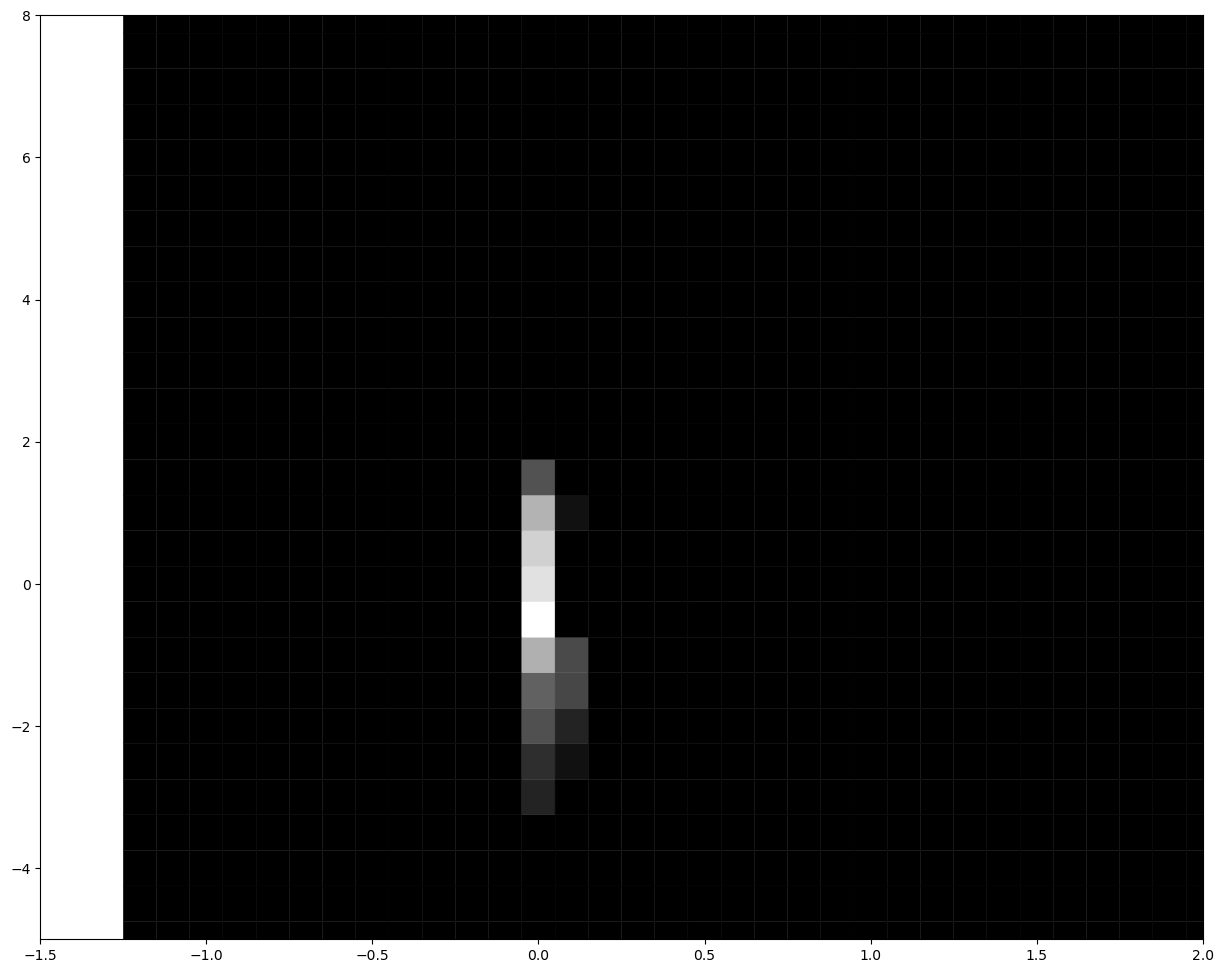

In [74]:
#If dMag and Color are not given, a 2-D array will be returned.
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

#Map = Enquiry(HashTable, InfoDict, 'g', 'i', 480, 1440)
Map = HashTable[0,1,1,1]
plt.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map)+1, edgecolors='face',
           norm=LogNorm(1, vmax=Map.max()+1), cmap='gist_gray')
plt.xlim([-1.5, 2])
plt.ylim([-5, 8])
# plt.axis('equal')

In [67]:
np.array([0,1]) == np.array(["v",3])

array([False, False])

ValueError: For X (51) and Y (39) with flat shading, A should have shape (38, 50, 3) or (38, 50, 4) or (38, 50) or (1900,), not (38, 50, 3, 3, 2, 2)

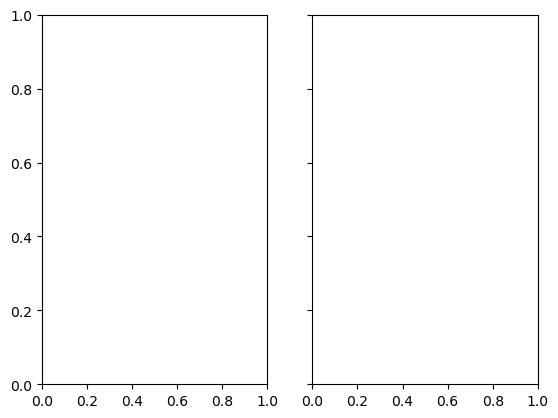

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
ax1.pcolormesh(InfoDict['BinMag'], InfoDict['BinColor'], HashTable.T[:,:], cmap='rainbow')